C:\Users\sahad2\AppData\Local\Temp\ipykernel_52792\1865104135.py:156: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  flooded_schools_gdf_latlong.plot(ax=ax, color='black', marker='o',  markersize=6, zorder=5, alpha=0.5)
C:\Users\sahad2\AppData\Local\Temp\ipykernel_52792\1865104135.py:157: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  dry_schools_gdf_latlong.plot(ax=ax, color='grey', marker='o', markersize=5, zorder=5)


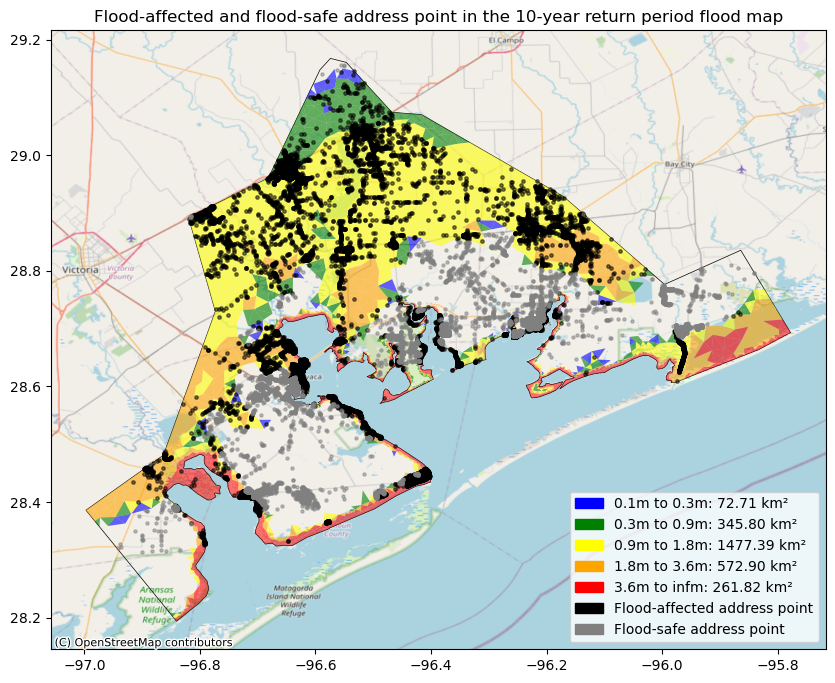

Depth range 0.1m to 0.3m: 72.71 square kilometers
Depth range 0.3m to 0.9m: 345.80 square kilometers
Depth range 0.9m to 1.8m: 1477.39 square kilometers
Depth range 1.8m to 3.6m: 572.90 square kilometers
Depth range 3.6m to infm: 261.82 square kilometers


In [17]:
import mikeio
import geopandas as gpd
import numpy as np
from shapely.geometry import Polygon
import matplotlib.pyplot as plt
import contextily as ctx

# Load the DFSU file and extract the desired item
dfsu_file = r"D:\Phd Research\Prototype HD Model\Simulation\Without Reef Scenarios\Climate change condition\10-yr return period storm CC.m21fm - Result Files\10-yr_CC_Stat.dfsu"
ds = mikeio.open(dfsu_file)
data = ds.read(items="Statistical maximum : Total water depth") 

# Load the shapefile for the land boundary
shapefile_path = r"D:\Phd Research\GIS\Shape\Project_Proposal\study_area_land_Part.zip"
land_boundary = gpd.read_file(shapefile_path)

# Load infrastructure shapefiles and set CRS (EPSG:32614)
shape_path2 = r"D:\Phd Research\Critical Infrastructure\Shape file\Address_point\stratmap24-addresspoints_48007_ap\shp\stratmap24-addresspoints_48007_aransas_202401.zip"
shape_path3 = r"D:\Phd Research\Critical Infrastructure\Shape file\Address_point\stratmap24-addresspoints_48057_ap\shp\stratmap24-addresspoints_48057_calhoun_202402.zip"
shape_path4 = r"D:\Phd Research\Critical Infrastructure\Shape file\Address_point\stratmap24-addresspoints_48239_ap\shp\stratmap24-addresspoints_48239_jackson_202401.zip"
shape_path5 = r"D:\Phd Research\Critical Infrastructure\Shape file\Address_point\stratmap24-addresspoints_48321_ap\shp\stratmap24-addresspoints_48321_matagorda_202407.zip"
shape_path6 = r"D:\Phd Research\Critical Infrastructure\Shape file\Address_point\stratmap24-addresspoints_48391_ap\shp\stratmap24-addresspoints_48391_refugio_202401.zip"
shape_path7 = r"D:\Phd Research\Critical Infrastructure\Shape file\Address_point\stratmap24-addresspoints_48469_ap\shp\stratmap24-addresspoints_48469_victoria_202401.zip"

school_point = gpd.read_file(shape_path2).to_crs(32614)
fire_point = gpd.read_file(shape_path3).to_crs(32614)
hos_point = gpd.read_file(shape_path4).to_crs(32614)
shelter_point = gpd.read_file(shape_path5).to_crs(32614)
ap5 = gpd.read_file(shape_path6).to_crs(32614)
ap6 = gpd.read_file(shape_path7).to_crs(32614)

# Perform spatial intersection with land boundary for each infrastructure type
school_intersect = gpd.overlay(school_point, land_boundary, how='intersection')
fire_intersect = gpd.overlay(fire_point, land_boundary, how='intersection')
hos_intersect = gpd.overlay(hos_point, land_boundary, how='intersection')
shelter_intersect = gpd.overlay(shelter_point, land_boundary, how='intersection')
ap5_intersect = gpd.overlay(ap5, land_boundary, how='intersection')
ap6_intersect = gpd.overlay(ap6, land_boundary, how='intersection')
# Extract geometry information from the DFSU file
geometry = ds.geometry
element_table = geometry.element_table
node_coordinates = geometry.node_coordinates

# Get water depth data
water_depth = data[0].to_numpy()

# Define depth ranges
depth_ranges = [
    (0.1, 0.3),
    (0.3, 0.9),
    (0.9, 1.8),
    (1.8, 3.6),
    (3.6, np.inf)
]

# Colors for plotting
colors = ['blue', 'green', 'yellow', 'orange', 'red']

# Initialize lists for storing polygons and areas by range
flooded_polygons_by_range = []
total_area_by_range = []

for low, high in depth_ranges:
    # Identify elements within the depth range
    flooded_elements = np.where((water_depth > low) & (water_depth <= high))[1]
    
    flooded_polygons = []
    for elem_idx in flooded_elements:
        nodes = element_table[elem_idx]
        coords = node_coordinates[nodes]
        polygon = Polygon(coords)
        flooded_polygons.append(polygon)
    
    # Create a GeoDataFrame for the flooded polygons
    flooded_area_gdf = gpd.GeoDataFrame(
        {'geometry': flooded_polygons},
        crs="EPSG:32614"  # Ensure CRS matches
    )
    
    # Clip the polygons with the land boundary shapefile
    flooded_area_clipped = gpd.overlay(flooded_area_gdf, land_boundary, how='intersection')
    
    # Calculate the total area for this depth range
    total_area = flooded_area_clipped.area.sum()
    total_area_by_range.append(total_area / 1e6)  # Convert to square kilometers
    
    flooded_polygons_by_range.append(flooded_area_clipped)

# Function to check if points fall inside flooded areas
def check_flooded(infrastructure, flooded_polygons_by_range):
    flooded = []
    dry = []
    for point in infrastructure.itertuples():
        is_flooded = False
        for flooded_area in flooded_polygons_by_range:
            if not flooded_area.empty and flooded_area.contains(point.geometry).any():
                is_flooded = True
                break
        if is_flooded:
            flooded.append(point.geometry)
        else:
            dry.append(point.geometry)
    return flooded, dry

# Check if schools, fire stations, hospitals, and shelters are flooded
flooded_schools, dry_schools = check_flooded(school_intersect, flooded_polygons_by_range)
flooded_fire, dry_fire = check_flooded(fire_intersect, flooded_polygons_by_range)
flooded_hos, dry_hos = check_flooded(hos_intersect, flooded_polygons_by_range)
flooded_shelter, dry_shelter = check_flooded(shelter_intersect, flooded_polygons_by_range)
flooded_ap5, dry_ap5 = check_flooded(ap5_intersect, flooded_polygons_by_range)
flooded_ap6, dry_ap6 = check_flooded(ap6_intersect, flooded_polygons_by_range)
# Convert lists to GeoDataFrames for plotting
flooded_schools_gdf = gpd.GeoDataFrame(geometry=flooded_schools, crs="EPSG:32614")
dry_schools_gdf = gpd.GeoDataFrame(geometry=dry_schools, crs="EPSG:32614")
flooded_fire_gdf = gpd.GeoDataFrame(geometry=flooded_fire, crs="EPSG:32614")
dry_fire_gdf = gpd.GeoDataFrame(geometry=dry_fire, crs="EPSG:32614")
flooded_hos_gdf = gpd.GeoDataFrame(geometry=flooded_hos, crs="EPSG:32614")
dry_hos_gdf = gpd.GeoDataFrame(geometry=dry_hos, crs="EPSG:32614")
flooded_shelter_gdf = gpd.GeoDataFrame(geometry=flooded_shelter, crs="EPSG:32614")
dry_shelter_gdf = gpd.GeoDataFrame(geometry=dry_shelter, crs="EPSG:32614")
flooded_ap5_gdf = gpd.GeoDataFrame(geometry=flooded_ap5, crs="EPSG:32614")
dry_ap5_gdf = gpd.GeoDataFrame(geometry=dry_ap5, crs="EPSG:32614")
flooded_ap6_gdf = gpd.GeoDataFrame(geometry=flooded_ap6, crs="EPSG:32614")
dry_ap6_gdf = gpd.GeoDataFrame(geometry=dry_ap6, crs="EPSG:32614")

# Reproject everything to Lat-Long (WGS 84)
land_boundary_latlong = land_boundary.to_crs(epsg=4326)
school_intersect_latlong = school_intersect.to_crs(epsg=4326)
fire_intersect_latlong = fire_intersect.to_crs(epsg=4326)
hos_intersect_latlong = hos_intersect.to_crs(epsg=4326)
shelter_intersect_latlong = shelter_intersect.to_crs(epsg=4326)
ap5_intersect_latlong = ap5_intersect.to_crs(epsg=4326)
ap6_intersect_latlong = ap6_intersect.to_crs(epsg=4326)

flooded_polygons_by_range_latlong = [polygons.to_crs(epsg=4326) for polygons in flooded_polygons_by_range]

# Convert flooded and dry infrastructure to Lat-Long (WGS 84)
flooded_schools_gdf_latlong = flooded_schools_gdf.to_crs(epsg=4326)
dry_schools_gdf_latlong = dry_schools_gdf.to_crs(epsg=4326)
flooded_fire_gdf_latlong = flooded_fire_gdf.to_crs(epsg=4326)
dry_fire_gdf_latlong = dry_fire_gdf.to_crs(epsg=4326)
flooded_hos_gdf_latlong = flooded_hos_gdf.to_crs(epsg=4326)
dry_hos_gdf_latlong = dry_hos_gdf.to_crs(epsg=4326)
flooded_shelter_gdf_latlong = flooded_shelter_gdf.to_crs(epsg=4326)
dry_shelter_gdf_latlong = dry_shelter_gdf.to_crs(epsg=4326)
flooded_ap5_gdf_latlong = flooded_ap5_gdf.to_crs(epsg=4326)
dry_ap5_gdf_latlong = dry_ap5_gdf.to_crs(epsg=4326)
flooded_ap6_gdf_latlong = flooded_ap6_gdf.to_crs(epsg=4326)
dry_ap6_gdf_latlong = dry_ap6_gdf.to_crs(epsg=4326)

# Plotting with Basemap and classification
fig, ax = plt.subplots(figsize=(10, 10))
land_boundary_latlong.plot(ax=ax, color='none', edgecolor='black', linewidth=0.5)

# Plot flooded and dry schools, fire stations, hospitals, and shelters
flooded_schools_gdf_latlong.plot(ax=ax, color='black', marker='o',  markersize=6, zorder=5, alpha=0.5)
dry_schools_gdf_latlong.plot(ax=ax, color='grey', marker='o', markersize=5, zorder=5)
flooded_fire_gdf_latlong.plot(ax=ax, color='black', marker='o', markersize=6, zorder=5, alpha=0.5)
dry_fire_gdf_latlong.plot(ax=ax, color='grey', marker='o', markersize=5, zorder=5, alpha=0.5)
flooded_hos_gdf_latlong.plot(ax=ax, color='black', marker='o', markersize=6, zorder=5, alpha=0.5)
dry_hos_gdf_latlong.plot(ax=ax, color='grey', marker='o', markersize=5, zorder=5, alpha=0.5)
flooded_shelter_gdf_latlong.plot(ax=ax, color='black', marker='o', markersize=6, zorder=5, alpha=0.5)
dry_shelter_gdf_latlong.plot(ax=ax, color='grey', marker='o', markersize=5, zorder=5, alpha=0.5)
flooded_ap5_gdf_latlong.plot(ax=ax, color='black', marker='o', markersize=6, zorder=5, alpha=0.5)
dry_ap5_gdf_latlong.plot(ax=ax, color='grey', marker='o', markersize=5, zorder=5, alpha=0.5)
flooded_ap6_gdf_latlong.plot(ax=ax, color='black', marker='o', markersize=6, zorder=5, alpha=0.5)
dry_ap6_gdf_latlong.plot(ax=ax, color='grey', marker='o', markersize=5, zorder=5, alpha=0.5)
# Plot each depth range with a different color in Lat-Long
for polygons, color in zip(flooded_polygons_by_range_latlong, colors):
    if not polygons.empty:
        polygons.plot(ax=ax, color=color, alpha=0.6, edgecolor='none')

# Add basemap in Lat-Long
ctx.add_basemap(ax, crs='EPSG:4326', source=ctx.providers.OpenStreetMap.Mapnik)

# Add a legend
import matplotlib.patches as mpatches
legend_patches = [
    mpatches.Patch(color=color, label=f'{low}m to {high}m: {area:.2f} km²') 
    for (low, high), color, area in zip(depth_ranges, colors, total_area_by_range)
] + [
    mpatches.Patch(color='black', label='Flood-affected address point'),
    mpatches.Patch(color='grey', label='Flood-safe address point')
]
ax.legend(handles=legend_patches, loc='lower right')

plt.title('Flood-affected and flood-safe address point in the 10-year return period flood map')
plt.show()

# Print the area for each range
for (low, high), area in zip(depth_ranges, total_area_by_range):
    print(f"Depth range {low}m to {high}m: {area:.2f} square kilometers")



In [20]:
num_flooded_schools = len(flooded_schools_gdf)
num_dry_schools = len(dry_schools_gdf)
total_schools = len(school_intersect)
num_flooded_ap5 = len(flooded_ap5_gdf)
num_dry_ap5 = len(dry_ap5_gdf)
total_ap5 = len(ap5_intersect)
num_flooded_ap6 = len(flooded_ap6_gdf)
num_dry_ap6 = len(dry_ap6_gdf)
total_ap6 = len(ap6_intersect)
# Calculate the percentages
# percent_flooded = (num_flooded_schools / total_schools) * 100
# percent_dry = (num_dry_schools / total_schools) * 100

# Print the number and percentage of flooded and dry schools
print(f"Number of flooded schools: {num_flooded_schools}")
print(f"Number of dry schools: {num_dry_schools}")
print(f"Percentage of flooded schools: {percent_flooded:.2f}%")
print(f"Percentage of dry schools: {percent_dry:.2f}%")
print(f"Number of flooded ap5: {num_flooded_ap5}")
print(f"Number of dry ap5: {num_dry_ap5}")
print(f"Number of flooded ap6: {num_flooded_ap6}")
print(f"Number of dry ap6: {num_dry_ap6}")
# Number of flooded and dry fire stations
num_flooded_fire = len(flooded_fire_gdf)
num_dry_fire = len(dry_fire_gdf)
total_fire = len(fire_intersect)

# Number of flooded and dry hospitals
num_flooded_hos = len(flooded_hos_gdf)
num_dry_hos = len(dry_hos_gdf)
total_hos = len(hos_intersect)

# Number of flooded and dry shelters
num_flooded_shelter = len(flooded_shelter_gdf)
num_dry_shelter = len(dry_shelter_gdf)
total_shelter = len(shelter_intersect)

# Calculate percentages for fire stations
percent_flooded_fire = (num_flooded_fire / total_fire) * 100
percent_dry_fire = (num_dry_fire / total_fire) * 100

# Calculate percentages for hospitals
percent_flooded_hos = (num_flooded_hos / total_hos) * 100
percent_dry_hos = (num_dry_hos / total_hos) * 100

# Calculate percentages for shelters
percent_flooded_shelter = (num_flooded_shelter / total_shelter) * 100
percent_dry_shelter = (num_dry_shelter / total_shelter) * 100

# Print the number and percentage of flooded and dry fire stations
print(f"Number of flooded fire stations: {num_flooded_fire}")
print(f"Number of dry fire stations: {num_dry_fire}")
print(f"Percentage of flooded fire stations: {percent_flooded_fire:.2f}%")
print(f"Percentage of dry fire stations: {percent_dry_fire:.2f}%")

# Print the number and percentage of flooded and dry hospitals
print(f"Number of flooded hospitals: {num_flooded_hos}")
print(f"Number of dry hospitals: {num_dry_hos}")
print(f"Percentage of flooded hospitals: {percent_flooded_hos:.2f}%")
print(f"Percentage of dry hospitals: {percent_dry_hos:.2f}%")

# Print the number and percentage of flooded and dry shelters
print(f"Number of flooded shelters: {num_flooded_shelter}")
print(f"Number of dry shelters: {num_dry_shelter}")
print(f"Percentage of flooded shelters: {percent_flooded_shelter:.2f}%")
print(f"Percentage of dry shelters: {percent_dry_shelter:.2f}%")


Number of flooded schools: 0
Number of dry schools: 0
Percentage of flooded schools: 85.71%
Percentage of dry schools: 14.29%
Number of flooded ap5: 387
Number of dry ap5: 225
Number of flooded ap6: 555
Number of dry ap6: 16
Number of flooded fire stations: 10456
Number of dry fire stations: 4464
Percentage of flooded fire stations: 70.08%
Percentage of dry fire stations: 29.92%
Number of flooded hospitals: 7551
Number of dry hospitals: 1028
Percentage of flooded hospitals: 88.02%
Percentage of dry hospitals: 11.98%
Number of flooded shelters: 3667
Number of dry shelters: 4257
Percentage of flooded shelters: 46.28%
Percentage of dry shelters: 53.72%


In [28]:
k = school_intersect.itertuples()


C:\Users\sahad2\AppData\Local\Temp\ipykernel_52792\3388725050.py:6: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  flooded_schools_gdf_latlong.plot(ax=ax, color='black', marker='o',  markersize=6, zorder=5, alpha=0.5)
C:\Users\sahad2\AppData\Local\Temp\ipykernel_52792\3388725050.py:7: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  dry_schools_gdf_latlong.plot(ax=ax, color='grey', marker='o', markersize=5, zorder=5)


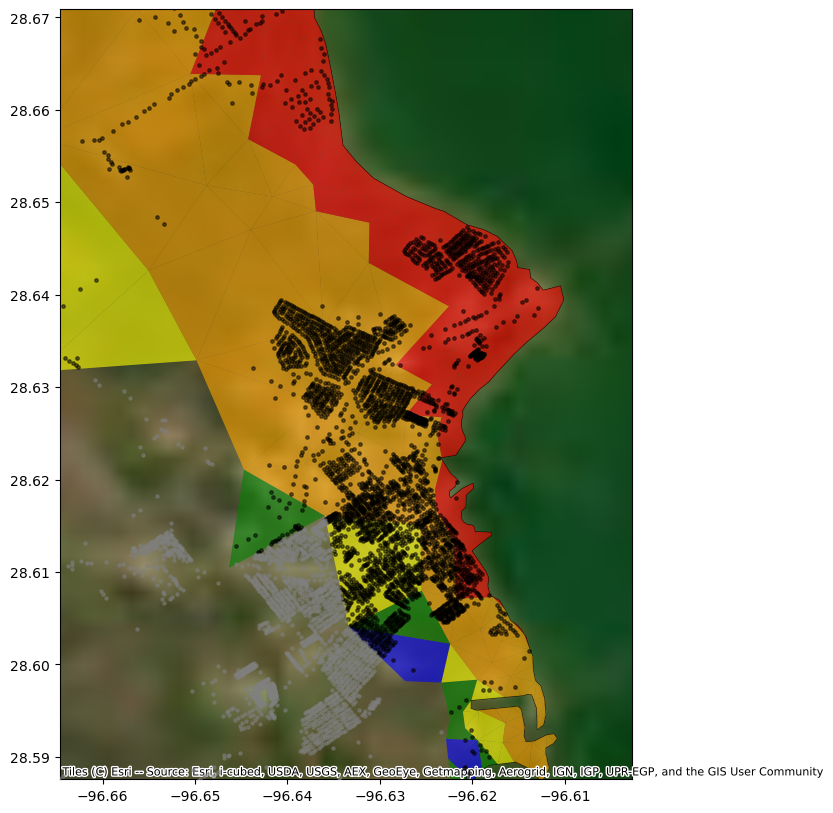

Depth range 0.1m to 0.3m: 72.71 square kilometers
Depth range 0.3m to 0.9m: 345.80 square kilometers
Depth range 0.9m to 1.8m: 1477.39 square kilometers
Depth range 1.8m to 3.6m: 572.90 square kilometers
Depth range 3.6m to infm: 261.82 square kilometers


In [24]:
# Plotting with Basemap and classification
fig, ax = plt.subplots(figsize=(10, 10))
land_boundary_latlong.plot(ax=ax, color='none', edgecolor='black', linewidth=0.5)

# Plot flooded and dry schools, fire stations, hospitals, and shelters
flooded_schools_gdf_latlong.plot(ax=ax, color='black', marker='o',  markersize=6, zorder=5, alpha=0.5)
dry_schools_gdf_latlong.plot(ax=ax, color='grey', marker='o', markersize=5, zorder=5)
flooded_fire_gdf_latlong.plot(ax=ax, color='black', marker='o', markersize=6, zorder=5, alpha=0.5)
dry_fire_gdf_latlong.plot(ax=ax, color='grey', marker='o', markersize=5, zorder=5, alpha=0.5)
flooded_hos_gdf_latlong.plot(ax=ax, color='black', marker='o', markersize=6, zorder=5, alpha=0.5)
dry_hos_gdf_latlong.plot(ax=ax, color='grey', marker='o', markersize=5, zorder=5, alpha=0.5)
flooded_shelter_gdf_latlong.plot(ax=ax, color='black', marker='o', markersize=6, zorder=5, alpha=0.5)
dry_shelter_gdf_latlong.plot(ax=ax, color='grey', marker='o', markersize=5, zorder=5, alpha=0.5)
flooded_ap5_gdf_latlong.plot(ax=ax, color='black', marker='o', markersize=6, zorder=5, alpha=0.5)
dry_ap5_gdf_latlong.plot(ax=ax, color='grey', marker='o', markersize=5, zorder=5, alpha=0.5)
flooded_ap6_gdf_latlong.plot(ax=ax, color='black', marker='o', markersize=6, zorder=5, alpha=0.5)
dry_ap6_gdf_latlong.plot(ax=ax, color='grey', marker='o', markersize=5, zorder=5, alpha=0.5)

# Plot each depth range with a different color in Lat-Long
for polygons, color in zip(flooded_polygons_by_range_latlong, colors):
    if not polygons.empty:
        polygons.plot(ax=ax, color=color, alpha=0.6, edgecolor='none')

# Add basemap in Lat-Long
# ctx.add_basemap(ax, crs='EPSG:4326', source=ctx.providers.OpenStreetMap.Mapnik)
# ctx.add_basemap(ax, crs='EPSG:4326', source=ctx.providers.Stamen.Terrain)
# ctx.add_basemap(ax, crs='EPSG:4326', source=ctx.providers.Esri.WorldStreetMap)
ctx.add_basemap(ax, crs='EPSG:4326', source=ctx.providers.Esri.WorldImagery)



# Set zoom area (latitude and longitude boundaries)
ax.set_xlim([-96.664647, -96.602727])  # Replace with desired longitude bounds
ax.set_ylim([28.587577, 28.670874])  # Replace with desired latitude bounds

# Add a legend
# import matplotlib.patches as mpatches
# legend_patches = [
#     mpatches.Patch(color=color, label=f'{low}m to {high}m: {area:.2f} km²') 
#     for (low, high), color, area in zip(depth_ranges, colors, total_area_by_range)
# ] + [
#     mpatches.Patch(color='cyan', label='Flood-affected CIs'),
#     mpatches.Patch(color='black', label='Flood-safe CIs')
# ]
# ax.legend(handles=legend_patches, loc='lower right')

# plt.title('Flood-affected and flood-safe critical infrastructure in the 10-year return period flood map')
plt.show()

# Print the area for each range
for (low, high), area in zip(depth_ranges, total_area_by_range):
    print(f"Depth range {low}m to {high}m: {area:.2f} square kilometers")


In [ ]:
import mikeio
import geopandas as gpd
import numpy as np
from shapely.geometry import Polygon
import matplotlib.pyplot as plt
import contextily as ctx

# Load the DFSU file and extract the desired item
dfsu_file = r"D:\Phd Research\Prototype HD Model\Simulation\Without Reef Scenarios\Climate change condition\10-yr return period storm CC.m21fm - Result Files\10-yr_CC_Stat.dfsu"
ds = mikeio.open(dfsu_file)
data = ds.read(items="Statistical maximum : Total water depth") 

# Load the shapefile for the land boundary
shapefile_path = r"D:\Phd Research\GIS\Shape\Project_Proposal\study_area_land_Part.zip"
land_boundary = gpd.read_file(shapefile_path)

# Load infrastructure shapefiles and set CRS (EPSG:32614)
shape_path2 = r"D:\Phd Research\Critical Infrastructure\Shape file\Schools2019to2020_372503062685561240.zip"
shape_path3 = r"D:\Phd Research\Critical Infrastructure\Shape file\Fire_and_Emergency_Medical_Service_(EMS)_Stations.zip"
shape_path4 = r"D:\Phd Research\Critical Infrastructure\Shape file\Hospitals.zip"
shape_path5 = r"D:\Phd Research\Critical Infrastructure\Shape file\National_Shelter_System_Facilities.zip"

school_point = gpd.read_file(shape_path2).to_crs(32614)
fire_point = gpd.read_file(shape_path3).to_crs(32614)
hos_point = gpd.read_file(shape_path4).to_crs(32614)
shelter_point = gpd.read_file(shape_path5).to_crs(32614)

# Perform spatial intersection with land boundary for each infrastructure type
school_intersect = gpd.overlay(school_point, land_boundary, how='intersection')
fire_intersect = gpd.overlay(fire_point, land_boundary, how='intersection')
hos_intersect = gpd.overlay(hos_point, land_boundary, how='intersection')
shelter_intersect = gpd.overlay(shelter_point, land_boundary, how='intersection')

# Extract geometry information from the DFSU file
geometry = ds.geometry
element_table = geometry.element_table
node_coordinates = geometry.node_coordinates

# Get water depth data
water_depth = data[0].to_numpy()

# Define depth ranges
depth_ranges = [
    (0.1, 0.3),
    (0.3, 0.9),
    (0.9, 1.8),
    (1.8, 3.6),
    (3.6, np.inf)
]

# Colors for plotting
colors = ['blue', 'green', 'yellow', 'orange', 'red']

# Initialize lists for storing polygons and areas by range
flooded_polygons_by_range = []
total_area_by_range = []

for low, high in depth_ranges:
    # Identify elements within the depth range
    flooded_elements = np.where((water_depth > low) & (water_depth <= high))[1]
    
    flooded_polygons = []
    for elem_idx in flooded_elements:
        nodes = element_table[elem_idx]
        coords = node_coordinates[nodes]
        polygon = Polygon(coords)
        flooded_polygons.append(polygon)
    
    # Create a GeoDataFrame for the flooded polygons
    flooded_area_gdf = gpd.GeoDataFrame(
        {'geometry': flooded_polygons},
        crs="EPSG:32614"  # Ensure CRS matches
    )
    
    # Clip the polygons with the land boundary shapefile
    flooded_area_clipped = gpd.overlay(flooded_area_gdf, land_boundary, how='intersection')
    
    # Calculate the total area for this depth range
    total_area = flooded_area_clipped.area.sum()
    total_area_by_range.append(total_area / 1e6)  # Convert to square kilometers
    
    flooded_polygons_by_range.append(flooded_area_clipped)

# Function to check if points fall inside flooded areas
def check_flooded(infrastructure, flooded_polygons_by_range):
    flooded = []
    dry = []
    for point in infrastructure.itertuples():
        is_flooded = False
        for flooded_area in flooded_polygons_by_range:
            if not flooded_area.empty and flooded_area.contains(point.geometry).any():
                is_flooded = True
                break
        if is_flooded:
            flooded.append(point.geometry)
        else:
            dry.append(point.geometry)
    return flooded, dry

# Check if schools, fire stations, hospitals, and shelters are flooded
flooded_schools, dry_schools = check_flooded(school_intersect, flooded_polygons_by_range)
flooded_fire, dry_fire = check_flooded(fire_intersect, flooded_polygons_by_range)
flooded_hos, dry_hos = check_flooded(hos_intersect, flooded_polygons_by_range)
flooded_shelter, dry_shelter = check_flooded(shelter_intersect, flooded_polygons_by_range)

# Convert lists to GeoDataFrames for plotting
flooded_schools_gdf = gpd.GeoDataFrame(geometry=flooded_schools, crs="EPSG:32614")
dry_schools_gdf = gpd.GeoDataFrame(geometry=dry_schools, crs="EPSG:32614")
flooded_fire_gdf = gpd.GeoDataFrame(geometry=flooded_fire, crs="EPSG:32614")
dry_fire_gdf = gpd.GeoDataFrame(geometry=dry_fire, crs="EPSG:32614")
flooded_hos_gdf = gpd.GeoDataFrame(geometry=flooded_hos, crs="EPSG:32614")
dry_hos_gdf = gpd.GeoDataFrame(geometry=dry_hos, crs="EPSG:32614")
flooded_shelter_gdf = gpd.GeoDataFrame(geometry=flooded_shelter, crs="EPSG:32614")
dry_shelter_gdf = gpd.GeoDataFrame(geometry=dry_shelter, crs="EPSG:32614")

# Reproject everything to Lat-Long (WGS 84)
land_boundary_latlong = land_boundary.to_crs(epsg=4326)
school_intersect_latlong = school_intersect.to_crs(epsg=4326)
fire_intersect_latlong = fire_intersect.to_crs(epsg=4326)
hos_intersect_latlong = hos_intersect.to_crs(epsg=4326)
shelter_intersect_latlong = shelter_intersect.to_crs(epsg=4326)

flooded_polygons_by_range_latlong = [polygons.to_crs(epsg=4326) for polygons in flooded_polygons_by_range]

# Convert flooded and dry infrastructure to Lat-Long (WGS 84)
flooded_schools_gdf_latlong = flooded_schools_gdf.to_crs(epsg=4326)
dry_schools_gdf_latlong = dry_schools_gdf.to_crs(epsg=4326)
flooded_fire_gdf_latlong = flooded_fire_gdf.to_crs(epsg=4326)
dry_fire_gdf_latlong = dry_fire_gdf.to_crs(epsg=4326)
flooded_hos_gdf_latlong = flooded_hos_gdf.to_crs(epsg=4326)
dry_hos_gdf_latlong = dry_hos_gdf.to_crs(epsg=4326)
flooded_shelter_gdf_latlong = flooded_shelter_gdf.to_crs(epsg=4326)
dry_shelter_gdf_latlong = dry_shelter_gdf.to_crs(epsg=4326)

# Plotting with Basemap and classification
fig, ax = plt.subplots(figsize=(10, 10))
land_boundary_latlong.plot(ax=ax, color='none', edgecolor='black', linewidth=0.5)

# Plot flooded and dry schools, fire stations, hospitals, and shelters
flooded_schools_gdf_latlong.plot(ax=ax, color='cyan', marker='o',  markersize=18, zorder=5, )
dry_schools_gdf_latlong.plot(ax=ax, color='black', marker='o', markersize=12, zorder=5)
flooded_fire_gdf_latlong.plot(ax=ax, color='cyan', marker='x', markersize=18, zorder=5)
dry_fire_gdf_latlong.plot(ax=ax, color='black', marker='x', markersize=12, zorder=5)
flooded_hos_gdf_latlong.plot(ax=ax, color='cyan', marker='^', markersize=18, zorder=5)
dry_hos_gdf_latlong.plot(ax=ax, color='black', marker='^', markersize=12, zorder=5)
flooded_shelter_gdf_latlong.plot(ax=ax, color='cyan', marker='s', markersize=18, zorder=5)
dry_shelter_gdf_latlong.plot(ax=ax, color='black', marker='s', markersize=12, zorder=5)

# Plot each depth range with a different color in Lat-Long
for polygons, color in zip(flooded_polygons_by_range_latlong, colors):
    if not polygons.empty:
        polygons.plot(ax=ax, color=color, alpha=0.6, edgecolor='none')

# Add basemap in Lat-Long
ctx.add_basemap(ax, crs='EPSG:4326', source=ctx.providers.OpenStreetMap.Mapnik)

# Add a legend
import matplotlib.patches as mpatches
legend_patches = [
    mpatches.Patch(color=color, label=f'{low}m to {high}m: {area:.2f} km²') 
    for (low, high), color, area in zip(depth_ranges, colors, total_area_by_range)
] + [
    mpatches.Patch(color='cyan', label='Flood-affected CIs'),
    mpatches.Patch(color='black', label='Flood-safe CIs')
]
ax.legend(handles=legend_patches, loc='lower right')

plt.title('Flood-affected and flood-safe critical infrastructure in the 10-year return period flood map')
plt.show()

# Print the area for each range
for (low, high), area in zip(depth_ranges, total_area_by_range):
    print(f"Depth range {low}m to {high}m: {area:.2f} square kilometers")
